# Libraries and functions

In [2]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt


def _find_representation_overlap_npz(results_dir, output_name=None, run_id=None):
    """
    Resolve the path to representation_overlaps.npz.

    Accepted inputs:
    1. results_dir = ".../results/output_name/run_id"
    2. results_dir = ".../results/output_name", run_id="..."
    3. results_dir = ".../results", output_name="...", run_id="..."
    """
    results_dir = Path(results_dir).expanduser()

    candidates = []

    if output_name is not None and run_id is not None:
        candidates.append(results_dir / output_name / run_id / "representation_overlaps.npz")

    if run_id is not None:
        candidates.append(results_dir / run_id / "representation_overlaps.npz")

    candidates.append(results_dir / "representation_overlaps.npz")

    for p in candidates:
        if p.exists():
            return p

    found = sorted(results_dir.glob("**/representation_overlaps.npz"))
    if len(found) == 1:
        return found[0]

    if len(found) > 1:
        raise RuntimeError(
            "Found more than one representation_overlaps.npz. "
            "Please specify output_name and/or run_id.\n"
            + "\n".join(str(p) for p in found[:20])
        )

    raise FileNotFoundError(f"Could not find representation_overlaps.npz under {results_dir}")


def _decode_np_string_array(arr):
    arr = np.asarray(arr)
    return [str(x) for x in arr.tolist()]


def _choose_time_axis(data, time_key="steps"):
    """
    Default: use selected_global_updates when available and valid.
    Fallback: selected_epochs.
    """
    if time_key in ("steps", "global_updates", "global_update"):
        if "selected_global_updates" in data.files:
            t = np.asarray(data["selected_global_updates"], dtype=float)
            if t.size > 0 and np.all(np.isfinite(t)) and np.any(t >= 0):
                return t, "steps"

    if time_key in ("epochs", "epoch"):
        if "selected_epochs" in data.files:
            return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    # automatic fallback
    if "selected_global_updates" in data.files:
        t = np.asarray(data["selected_global_updates"], dtype=float)
        if t.size > 0 and np.all(np.isfinite(t)) and np.any(t >= 0):
            return t, "steps"

    if "selected_epochs" in data.files:
        return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    raise KeyError("Could not find selected_global_updates or selected_epochs in the npz file.")


def _resolve_reference_indices(times, reference_times=None, reference_indices=None):
    times = np.asarray(times, dtype=float)

    if reference_indices is not None:
        ref_idx = np.asarray(reference_indices, dtype=int)
        if np.any(ref_idx < 0) or np.any(ref_idx >= len(times)):
            raise ValueError(f"reference_indices must be in [0, {len(times)-1}]")
        return ref_idx

    if reference_times is None:
        # default: beginning, middle, end
        ref_idx = np.unique(
            np.asarray([0, len(times) // 2, len(times) - 1], dtype=int)
        )
        return ref_idx

    ref_idx = []
    for t0 in reference_times:
        j = int(np.argmin(np.abs(times - float(t0))))
        ref_idx.append(j)

    return np.unique(np.asarray(ref_idx, dtype=int))


def _resolve_layer_indices(layer_names, layers=None):
    if layers is None:
        return np.arange(len(layer_names), dtype=int)

    out = []
    for layer in layers:
        if isinstance(layer, str):
            if layer not in layer_names:
                raise ValueError(f"Layer {layer!r} not found. Available: {layer_names}")
            out.append(layer_names.index(layer))
        else:
            j = int(layer)
            if j < 0 or j >= len(layer_names):
                raise ValueError(f"Layer index {j} outside [0, {len(layer_names)-1}]")
            out.append(j)

    return np.asarray(out, dtype=int)


def plot_representation_self_overlap_vs_time(
    results_dir,
    output_name=None,
    run_id=None,
    split="test",
    reference_times=None,
    reference_indices=None,
    layers=None,
    time_key="steps",
    x_mode="absolute",
    only_t_ge_tprime=True,
    figsize_per_panel=(6.0, 4.2),
    ncols=3,
    ylim=(0.0, 1.05),
    marker="o",
    linewidth=1.8,
    alpha=0.9,
    title_prefix=None,
):
    """
    Plot q_l(t, t') for fixed reference times t', for all selected layers.

    Parameters
    ----------
    results_dir:
        Path to results/output_name/run_id, or to results/output_name, or to results.

    output_name, run_id:
        Optional, used to resolve the folder.

    split:
        "train" or "test".

    reference_times:
        Values of t' in the chosen time axis. The closest available saved time is used.

    reference_indices:
        Alternative to reference_times. Direct indices in the selected-checkpoint list.

    layers:
        None means all layers. Otherwise list of layer names or indices, e.g.
        ["embedding", "block_1", "block_3"] or [0, 1, 3].

    time_key:
        "steps" uses selected_global_updates if available; otherwise it falls back to epochs.
        "epochs" uses selected_epochs.

    x_mode:
        "absolute": x-axis is t.
        "delta": x-axis is t - t'.

    only_t_ge_tprime:
        If True, keep only t >= t'. This is usually what you want for aging-style plots.

    Returns
    -------
    fig, axs, info
    """
    npz_path = _find_representation_overlap_npz(
        results_dir,
        output_name=output_name,
        run_id=run_id,
    )
    data = np.load(npz_path, allow_pickle=True)

    key = f"{split}_cka"
    if key not in data.files:
        raise KeyError(f"{key!r} not found. Available keys: {data.files}")

    q = np.asarray(data[key], dtype=float)  # [num_layers, K, K]
    times, actual_time_key = _choose_time_axis(data, time_key=time_key)

    if "layer_names" in data.files:
        layer_names = _decode_np_string_array(data["layer_names"])
    else:
        layer_names = [f"layer_{i}" for i in range(q.shape[0])]

    layer_idx = _resolve_layer_indices(layer_names, layers=layers)
    ref_idx = _resolve_reference_indices(
        times,
        reference_times=reference_times,
        reference_indices=reference_indices,
    )

    nrefs = len(ref_idx)
    ncols_eff = min(int(ncols), nrefs)
    nrows = math.ceil(nrefs / ncols_eff)

    fig, axs = plt.subplots(
        nrows,
        ncols_eff,
        figsize=(figsize_per_panel[0] * ncols_eff, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    axs_flat = axs.ravel()

    for ax, j_ref in zip(axs_flat, ref_idx):
        t_ref = times[j_ref]

        if only_t_ge_tprime:
            mask = times >= t_ref
        else:
            mask = np.ones_like(times, dtype=bool)

        x = times[mask]
        if x_mode == "delta":
            x = x - t_ref
            xlabel = rf"$t - t'$ ({actual_time_key})"
        elif x_mode == "absolute":
            xlabel = rf"$t$ ({actual_time_key})"
        else:
            raise ValueError("x_mode must be 'absolute' or 'delta'.")

        for l in layer_idx:
            # q_l(t, t') = CKA between checkpoint t and reference checkpoint t'
            y = q[l, mask, j_ref]
            ax.plot(
                x,
                y,
                marker=marker,
                linewidth=linewidth,
                alpha=alpha,
                label=layer_names[l],
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(rf"$q_\ell(t,t')$")
        ax.set_ylim(*ylim)
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)

        if title_prefix is None:
            title = f"{split} overlap, reference t'={t_ref:g} {actual_time_key}"
        else:
            title = f"{title_prefix}, reference t'={t_ref:g} {actual_time_key}"
        ax.set_title(title)

        ax.legend(fontsize=8, frameon=False)

    for ax in axs_flat[nrefs:]:
        ax.axis("off")

    fig.tight_layout()

    info = {
        "npz_path": str(npz_path),
        "split": split,
        "time_key_used": actual_time_key,
        "times": times,
        "reference_indices": ref_idx,
        "reference_times_available": times[ref_idx],
        "layer_indices": layer_idx,
        "layer_names": [layer_names[i] for i in layer_idx],
        "q_shape": q.shape,
    }

    return fig, axs, info

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl



def plot_err_vs_norm_all_curves(
    data,
    norm_type="spectral_complexity",
    y_plot="error",
    M_l_split="test",
    logit_split="test",
    M_l_levels=None,
    M_l_linestyles=None,
    show_M_l_level_legend=True,
    ax=None,
    figsize=(7, 5),
    lw=1.5,
    alpha=0.9,
    use_log_color=True,
    xscale="linear",
    yscale="linear",
    add_colorbar=True,
    title=None,
    average_seeds=False,
    avg_num_x=200,
    avg_min_count=1,
    return_avg_data=False,
):
    """
    Plot test error or another observable versus a chosen norm/time.

    New feature
    -----------
    You can now use the fourth M_l quantity, namely the level-wise peeled-loss
    contribution,

        < log(1 + exp(-M_l)) >

    either as y-axis or x-axis by setting:

        y_plot="M_l_peeled_loss"

    or

        norm_type="M_l_peeled_loss"

    You can also plot the level-wise solved/unsolved fractions using:

        y_plot="M_l_pos_frac"      # P(M_l > 0)
        y_plot="M_l_neg_frac"      # 1 - P(M_l > 0), i.e. P(M_l <= 0)

    The negative/unsolved fraction is useful with yscale="log", because it
    decays toward zero as the level is solved.

    You can also plot the output-logit effective dimension saved by the
    modified collect_results.py by setting, for example:

        y_plot="logit_effdim_entropy"
        y_plot="logit_effdim_pr"
        y_plot="logit_effdim_entropy_norm"
        y_plot="logit_effdim_pr_norm"

    or use one of these as x-axis via norm_type.

    The M_l split is selected by:

        M_l_split="train" or "test"

    The logit effective-dimension split is selected by:

        logit_split="train" or "test"

    Different P values keep the same color rule as before.
    Different hierarchy levels l are distinguished by linestyle.

    Parameters
    ----------
    data : dict
        Loaded npy dictionary:
        data = np.load(path, allow_pickle=True).item()

    norm_type : str
        "spectral_complexity", "spectral_complexity_no_QK", "l2",
        "margin_std", "time", "M_l_peeled_loss",
        "logit_effdim_entropy", "logit_effdim_pr",
        "logit_effdim_entropy_norm", or "logit_effdim_pr_norm".

    y_plot : str
        "error", "train_loss", "test_loss", "spectral_complexity",
        "spectral_complexity_no_QK", "l2", "margin_std", "margin_mean",
        "margin_min", "margin_max", "M_l_peeled_loss",
        "logit_effdim_entropy", "logit_effdim_pr",
        "logit_effdim_entropy_norm", or "logit_effdim_pr_norm".

    M_l_split : str
        "train" or "test". Selects whether M_l_peeled_loss comes from
        train_rhm_level_penalty_mean_seeds or test_rhm_level_penalty_mean_seeds.

    logit_split : str
        "train" or "test". Selects whether logit effective dimension comes from
        train_logit_effdim_*_seeds or test_logit_effdim_*_seeds.

    M_l_levels : list[int] or None
        Levels to plot, using 1-based labels. Example: [1, 3].
        If None, plot all available levels.

    M_l_linestyles : list[str] or None
        Linestyle cycle for different levels. Default:
        ["-", "--", "-.", ":"].

    average_seeds : bool
        If False, plot all seed curves.
        If True, average curves across seeds for each P and each level after
        interpolation on a single global log-spaced x-grid.

    avg_num_x : int
        Number of points in the common x-grid used for averaging.

    avg_min_count : int
        Minimum number of non-NaN seed contributions required at a grid point
        to plot the averaged curve there.

    return_avg_data : bool
        If True, also return a dictionary containing the common grid and the
        averaged/interpolated curves.
    """

    if M_l_split not in ("train", "test"):
        raise ValueError("M_l_split must be either 'train' or 'test'.")
    if logit_split not in ("train", "test"):
        raise ValueError("logit_split must be either 'train' or 'test'.")

    if M_l_linestyles is None:
        M_l_linestyles = ["-", "--", "-.", ":"]

    def _is_M_l_negative_request(name):
        return name in {
            "M_l_neg_frac",
            "Ml_neg_frac",
            "M_l_negative_frac",
            "M_l_fraction_negative",
            "M_l_frac_negative",
            "fraction_M_l_negative",
            "frac_M_l_negative",
            "rhm_M_neg_frac",
            "M_l_unsolved_frac",
            "Ml_unsolved_frac",
            "M_l_fraction_unsolved",
            "M_l_frac_unsolved",
            "fraction_M_l_unsolved",
            "frac_M_l_unsolved",
            "rhm_M_unsolved_frac",
        }

    def _M_l_quantity_info(name):
        """
        Return:
            key_suffix, label
    
        where the full data key is:
            f"{M_l_split}_{key_suffix}_seeds"
        """
        if name in {
            "M_l_peeled_loss",
            "Ml_peeled_loss",
            "rhm_level_penalty",
            "rhm_level_penalty_mean",
            "level_penalty",
            "peeled_loss",
        }:
            return (
                "rhm_level_penalty_mean",
                rf"{M_l_split} peeled loss $\langle \log(1+e^{{-M_\ell}})\rangle$",
            )
    
        if name in {
            "M_l_pos_frac",
            "Ml_pos_frac",
            "M_l_fraction_positive",
            "M_l_frac_positive",
            "fraction_M_l_positive",
            "frac_M_l_positive",
            "rhm_M_pos_frac",
        }:
            return (
                "rhm_M_pos_frac",
                rf"{M_l_split} fraction $\mathbb{{P}}(M_\ell>0)$",
            )
    

        if _is_M_l_negative_request(name):
            return (
                "rhm_M_pos_frac",
                rf"{M_l_split} fraction $\mathbb{{P}}(M_\ell\leq 0)$",
            )

        return None, None

 
    def _is_M_l_request(name):
        key_suffix, _ = _M_l_quantity_info(name)
        return key_suffix is not None
    
    
    def _get_M_l_array(data, split, quantity_name):
        key_suffix, label = _M_l_quantity_info(quantity_name)
    
        if key_suffix is None:
            raise ValueError(f"Unknown M_l quantity: {quantity_name}")
    
        key = f"{split}_{key_suffix}_seeds"
    
        if key not in data:
            raise KeyError(
                f"Could not find '{key}' in data. "
                "You need to run the modified collect_results.py that stores M_l quantities."
            )
    
        arr = np.asarray(data[key], dtype=float)

        if _is_M_l_negative_request(quantity_name):
            # collect_results.py stores P(M_l > 0). The unsolved/negative
            # probability is therefore the complement. Strictly speaking this is
            # P(M_l <= 0); ties at exactly zero are negligible for real-valued logits.
            arr = 1.0 - arr
    
        if arr.ndim != 4:
            raise ValueError(
                f"Expected {key} to have shape (nP, nT, nS, L), got {arr.shape}."
            )
    
        return arr, label

    def _strip_optional_split_prefix(name):
        """Allow names such as test_logit_effdim_entropy."""
        if isinstance(name, str) and name.startswith("train_"):
            return "train", name[len("train_"):]
        if isinstance(name, str) and name.startswith("test_"):
            return "test", name[len("test_"):]
        return None, name

    def _logit_quantity_info(name):
        """
        Return:
            key_suffix, label

        where the full collect_results key is normally:
            f"{logit_split}_{key_suffix}_seeds"
        """
        _, bare = _strip_optional_split_prefix(name)

        if bare in {
            "logit_effdim_entropy",
            "effdim_entropy",
            "entropy_effdim",
            "entropy_effective_dimension",
            "effective_dimension_entropy",
            "D_entropy",
        }:
            return (
                "logit_effdim_entropy",
                rf"{logit_split} logit entropy effective dimension",
            )

        if bare in {
            "logit_effdim_pr",
            "effdim_pr",
            "pr_effdim",
            "participation_effdim",
            "participation_ratio_dimension",
            "D_pr",
        }:
            return (
                "logit_effdim_pr",
                rf"{logit_split} logit participation-ratio dimension",
            )

        if bare in {
            "logit_effdim_entropy_norm",
            "effdim_entropy_norm",
            "entropy_effdim_norm",
            "normalized_entropy_effdim",
        }:
            return (
                "logit_effdim_entropy_norm",
                rf"{logit_split} normalized logit entropy effective dimension",
            )

        if bare in {
            "logit_effdim_pr_norm",
            "effdim_pr_norm",
            "pr_effdim_norm",
            "normalized_pr_effdim",
        }:
            return (
                "logit_effdim_pr_norm",
                rf"{logit_split} normalized logit participation-ratio dimension",
            )

        if bare in {
            "logit_energy_mean",
            "logit_energy",
            "output_logit_energy",
        }:
            return (
                "logit_energy_mean",
                rf"{logit_split} mean centered-logit energy",
            )

        if bare in {
            "logit_input_variance",
            "logit_variance",
            "output_logit_variance",
        }:
            return (
                "logit_input_variance",
                rf"{logit_split} logit input variance",
            )

        return None, None

    def _is_logit_request(name):
        key_suffix, _ = _logit_quantity_info(name)
        return key_suffix is not None

    def _get_logit_array(data, split, quantity_name):
        explicit_split, bare_name = _strip_optional_split_prefix(quantity_name)
        split_to_use = explicit_split if explicit_split is not None else split

        key_suffix, _ = _logit_quantity_info(bare_name)
        if key_suffix is None:
            raise ValueError(f"Unknown logit effective-dimension quantity: {quantity_name}")

        label_map = {
            "logit_effdim_entropy": rf"{split_to_use} logit entropy effective dimension",
            "logit_effdim_pr": rf"{split_to_use} logit participation-ratio dimension",
            "logit_effdim_entropy_norm": rf"{split_to_use} normalized logit entropy effective dimension",
            "logit_effdim_pr_norm": rf"{split_to_use} normalized logit participation-ratio dimension",
            "logit_energy_mean": rf"{split_to_use} mean centered-logit energy",
            "logit_input_variance": rf"{split_to_use} logit input variance",
        }
        label = label_map[key_suffix]

        key = f"{split_to_use}_{key_suffix}_seeds"
        if key not in data:
            available = [k for k in data.keys() if "logit" in str(k)]
            raise KeyError(
                f"Could not find '{key}' in data. "
                "You need the modified collect_results.py output that stores logit effective-dimension quantities. "
                f"Available logit-like keys: {available[:30]}"
            )

        arr = np.asarray(data[key], dtype=float)
        if arr.ndim != 3:
            raise ValueError(
                f"Expected {key} to have shape (nP, nT, nS), got {arr.shape}."
            )

        return arr, label

    def _get_y_array(data, y_plot):
        if _is_M_l_request(y_plot):
            arr, label = _get_M_l_array(data, M_l_split, y_plot)
            return arr, label, True
        if _is_logit_request(y_plot):
            arr, label = _get_logit_array(data, logit_split, y_plot)
            return arr, label, False

        if y_plot == "error":
            return np.asarray(data["err_seeds"]), "test error", False
        elif y_plot == "train_loss":
            return np.asarray(data["trainloss_seeds"]), "train loss", False
        elif y_plot == "test_loss":
            return np.asarray(data["testloss_seeds"]), "test loss", False
        elif y_plot == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm", False
        elif y_plot == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm no QK", False
        elif y_plot == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm", False
        elif y_plot == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale", False
        elif y_plot == "margin_mean":
            return np.asarray(data["margin_mean_seeds"]), "Margin mean", False
        elif y_plot == "margin_min":
            return np.asarray(data["margin_min_seeds"]), "Margin min", False
        elif y_plot == "margin_max":
            return np.asarray(data["margin_max_seeds"]), "Margin max", False
        else:
            raise ValueError(
                "y_plot must be one of: "
                "'error', 'train_loss', 'test_loss', 'spectral_complexity', "
                "'spectral_complexity_no_QK', 'l2', 'margin_std', "
                "'margin_mean', 'margin_min', 'margin_max', 'M_l_peeled_loss', "
                "'M_l_pos_frac', 'M_l_neg_frac'."
            )

    def _get_x_array(data, norm_type, base_shape, P_values):
        if _is_M_l_request(norm_type):
            arr, label = _get_M_l_array(data, M_l_split, norm_type)
            return arr, label, True
        if _is_logit_request(norm_type):
            arr, label = _get_logit_array(data, logit_split, norm_type)
            return arr, label, False

        if norm_type == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm", False
        elif norm_type == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm no QK", False
        elif norm_type == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm", False
        elif norm_type == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale", False
        elif norm_type == "time":
            t_arr = np.asarray(data["T_arr"])
            x = np.broadcast_to(
                t_arr[None, :, None],
                (base_shape[0], base_shape[1], base_shape[2])
            ).astype(float)
            for iP, P in enumerate(P_values):
                x[iP, :, :] = x[iP, :, :] 
            return x, "t", False
        else:
            raise ValueError(
                "norm_type must be one of: "
                "'spectral_complexity', 'spectral_complexity_no_QK', 'l2', "
                "'margin_std', 'time', 'M_l_peeled_loss', "
                "'M_l_pos_frac', 'M_l_neg_frac'."
            )

    def _valid_curve(x, y, xscale, yscale, drop_first_n=2):
        x = np.asarray(x, dtype=float)[drop_first_n:]
        y = np.asarray(y, dtype=float)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= (x > 0)
        if yscale == "log":
            mask &= (y > 0)

        x = x[mask]
        y = y[mask]

        if x.size < 2:
            return None, None

        order = np.argsort(x)
        x = x[order]
        y = y[order]

        x_unique, unique_idx = np.unique(x, return_index=True)
        y_unique = y[unique_idx]

        if x_unique.size < 2:
            return None, None

        return x_unique, y_unique

    def _interp_on_log_grid(x, y, x_grid):
        return np.interp(
            np.log10(x_grid),
            np.log10(x),
            y,
            left=np.nan,
            right=np.nan,
        )

    def _get_curve(arr, iP, iseed, iL):
        """
        arr can be:
        - scalar diagnostic: shape (nP, nT, nS)
        - level diagnostic:  shape (nP, nT, nS, L)
        """
        if arr.ndim == 3:
            return arr[iP, :, iseed]
        elif arr.ndim == 4:
            return arr[iP, :, iseed, iL]
        else:
            raise ValueError(f"Unsupported array shape: {arr.shape}")

    def _level_style(iL):
        return M_l_linestyles[iL % len(M_l_linestyles)]

    P_values = np.asarray(data["P_values"])
    num_seeds = np.asarray(data["num_seeds"])

    y_seeds, ylabel, y_is_levelwise = _get_y_array(data, y_plot)

    # Use the non-level shape as reference if y is levelwise.
    if y_seeds.ndim == 4:
        base_shape = y_seeds.shape[:3]
    else:
        base_shape = y_seeds.shape

    x_seeds, xlabel, x_is_levelwise = _get_x_array(data, norm_type, base_shape, P_values)

    if y_seeds.ndim not in (3, 4):
        raise ValueError(f"y array must have ndim 3 or 4, got shape {y_seeds.shape}.")
    if x_seeds.ndim not in (3, 4):
        raise ValueError(f"x array must have ndim 3 or 4, got shape {x_seeds.shape}.")

    nP, nT, nS = base_shape

    # Determine number of level curves.
    if x_seeds.ndim == 4 and y_seeds.ndim == 4:
        nL = min(x_seeds.shape[-1], y_seeds.shape[-1])
    elif x_seeds.ndim == 4:
        nL = x_seeds.shape[-1]
    elif y_seeds.ndim == 4:
        nL = y_seeds.shape[-1]
    else:
        nL = 1

    if M_l_levels is None:
        level_indices = list(range(nL))
    else:
        # User gives levels as 1-based labels.
        level_indices = [int(l) - 1 for l in M_l_levels]
        bad = [l + 1 for l in level_indices if l < 0 or l >= nL]
        if bad:
            raise ValueError(f"Requested M_l_levels {bad} outside available levels 1,...,{nL}.")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    cmap = mpl.cm.get_cmap("viridis")

    if len(P_values) == 1:
        def color_of_P(P):
            return cmap(1.0)
        sm = None
    else:
        if use_log_color:
            color_norm = mpl.colors.LogNorm(
                vmin=np.min(P_values),
                vmax=np.max(P_values) + 10000
            )
        else:
            color_norm = mpl.colors.Normalize(
                vmin=np.min(P_values),
                vmax=np.max(P_values)
            )

        def color_of_P(P):
            return cmap(color_norm(P))

        sm = mpl.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])

    avg_data = {
        "P_values": P_values.copy(),
        "levels": np.array([i + 1 for i in level_indices], dtype=int),
        "x_grid": None,
        "mean_curves": None,
        "counts": None,
        "interpolated_curves": None,
    }

    if not average_seeds:
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            for iL in level_indices:
                ls = _level_style(iL)

                for iseed in range(num_seeds[iP]):
                    x = _get_curve(x_seeds, iP, iseed, iL)
                    y = _get_curve(y_seeds, iP, iseed, iL)

                    x, y = _valid_curve(x, y, xscale, yscale, drop_first_n=2)
                    if x is None:
                        continue

                    ax.plot(
                        x,
                        y,
                        color=this_color,
                        linestyle=ls,
                        lw=lw,
                        alpha=alpha,
                    )

    else:
        # ---------------------------------------------------------
        # 1) build one global log-spaced x-grid from ALL valid curves
        # ---------------------------------------------------------
        global_x_min = np.inf
        global_x_max = -np.inf

        for iP in range(nP):
            for iL in level_indices:
                for iseed in range(num_seeds[iP]):
                    x = _get_curve(x_seeds, iP, iseed, iL)
                    y = _get_curve(y_seeds, iP, iseed, iL)

                    x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                    if x_valid is None:
                        continue

                    global_x_min = min(global_x_min, np.min(x_valid))
                    global_x_max = max(global_x_max, np.max(x_valid))

        if not np.isfinite(global_x_min) or not np.isfinite(global_x_max):
            raise ValueError("No valid positive x values found to build the common log-spaced grid.")

        if global_x_min <= 0:
            raise ValueError("Global x-grid for averaging requires strictly positive x values.")

        x_grid = np.logspace(np.log10(global_x_min), np.log10(global_x_max), avg_num_x)

        nL_plot = len(level_indices)
        mean_curves = np.full((nP, nL_plot, avg_num_x), np.nan, dtype=float)
        counts = np.zeros((nP, nL_plot, avg_num_x), dtype=int)
        interpolated_curves = np.full((nP, nL_plot, nS, avg_num_x), np.nan, dtype=float)

        # ---------------------------------------------------------
        # 2) interpolate each seed curve on that common grid
        # 3) average across seeds for each P and each level
        # ---------------------------------------------------------
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            for local_l_idx, iL in enumerate(level_indices):
                ls = _level_style(iL)
                interp_list = []

                for iseed in range(num_seeds[iP]):
                    x = _get_curve(x_seeds, iP, iseed, iL)
                    y = _get_curve(y_seeds, iP, iseed, iL)

                    x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                    if x_valid is None:
                        continue

                    y_interp = _interp_on_log_grid(x_valid, y_valid, x_grid)
                    interp_list.append(y_interp)
                    interpolated_curves[iP, local_l_idx, iseed, :] = y_interp

                if len(interp_list) == 0:
                    continue

                interp_arr = np.asarray(interp_list)
                mean_curve = np.nanmean(interp_arr, axis=0)
                count_curve = np.sum(np.isfinite(interp_arr), axis=0)

                mean_curve[count_curve < avg_min_count] = np.nan

                mean_curves[iP, local_l_idx, :] = mean_curve
                counts[iP, local_l_idx, :] = count_curve

                mask_plot = np.isfinite(mean_curve)
                if np.any(mask_plot):
                    ax.plot(
                        x_grid[mask_plot],
                        mean_curve[mask_plot],
                        color=this_color,
                        linestyle=ls,
                        lw=lw,
                        alpha=alpha,
                    )

        avg_data["x_grid"] = x_grid
        avg_data["mean_curves"] = mean_curves
        avg_data["counts"] = counts
        avg_data["interpolated_curves"] = interpolated_curves

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and sm is not None:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("P")

    # Add a separate legend for the M_l levels when a level-wise quantity is involved.
    if show_M_l_level_legend and (x_is_levelwise or y_is_levelwise):
        handles = []
        labels = []
        for iL in level_indices:
            h = mpl.lines.Line2D(
                [0],
                [0],
                color="black",
                linestyle=_level_style(iL),
                lw=lw,
                label=rf"$\ell={iL+1}$",
            )
            handles.append(h)
            labels.append(rf"$\ell={iL+1}$")

        ax.legend(
            handles=handles,
            labels=labels,
            title=r"$M_\ell$ level",
            frameon=False,
            fontsize=10,
            title_fontsize=10,
        )

    plt.tight_layout()

    if return_avg_data:
        return fig, ax, avg_data
    return fig, ax

# Results

## Init scale = 0.8, L=3, 3-layer

In [8]:
res = np.load("results/save_uniform_M_L3_v1.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'timestep_values', 'T_arr_timestep', 'num_seeds', 'seed_triplets', 'rhm_M_l_num_levels', 'rhm_M_l_num_levels_timestep', 'trainloss_raw', 'trainloss_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'trainloss_timestep_raw', 'trainloss_seeds_timestep', 'trainloss_timestep_mean', 'trainloss_timestep_std', 'trainloss_timestep_n', 'trainacc_raw', 'trainacc_seeds', 'trainacc_mean', 'trainacc_std', 'trainacc_n', 'trainacc_timestep_raw', 'trainacc_seeds_timestep', 'trainacc_timestep_mean', 'trainacc_timestep_std', 'trainacc_timestep_n', 'trainerr_raw', 'trainerr_seeds', 'trainerr_mean', 'trainerr_std', 'trainerr_n', 'trainerr_timestep_raw', 'trainerr_seeds_timestep', 'trainerr_timestep_mean', 'trainerr_timestep_std', 'trainerr_timestep_n', 'testloss_raw', 'testloss_seeds', 'testloss_mean', 'testloss_std', 'testloss_n', 'testloss_timestep_raw', 'testloss_seeds_timestep', 'testloss_timestep_me

/tmp/ipykernel_15494/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

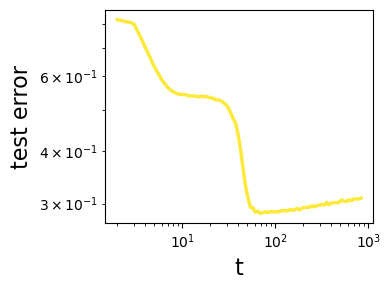

In [9]:
res = np.load("results/save_uniform_M_L3_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


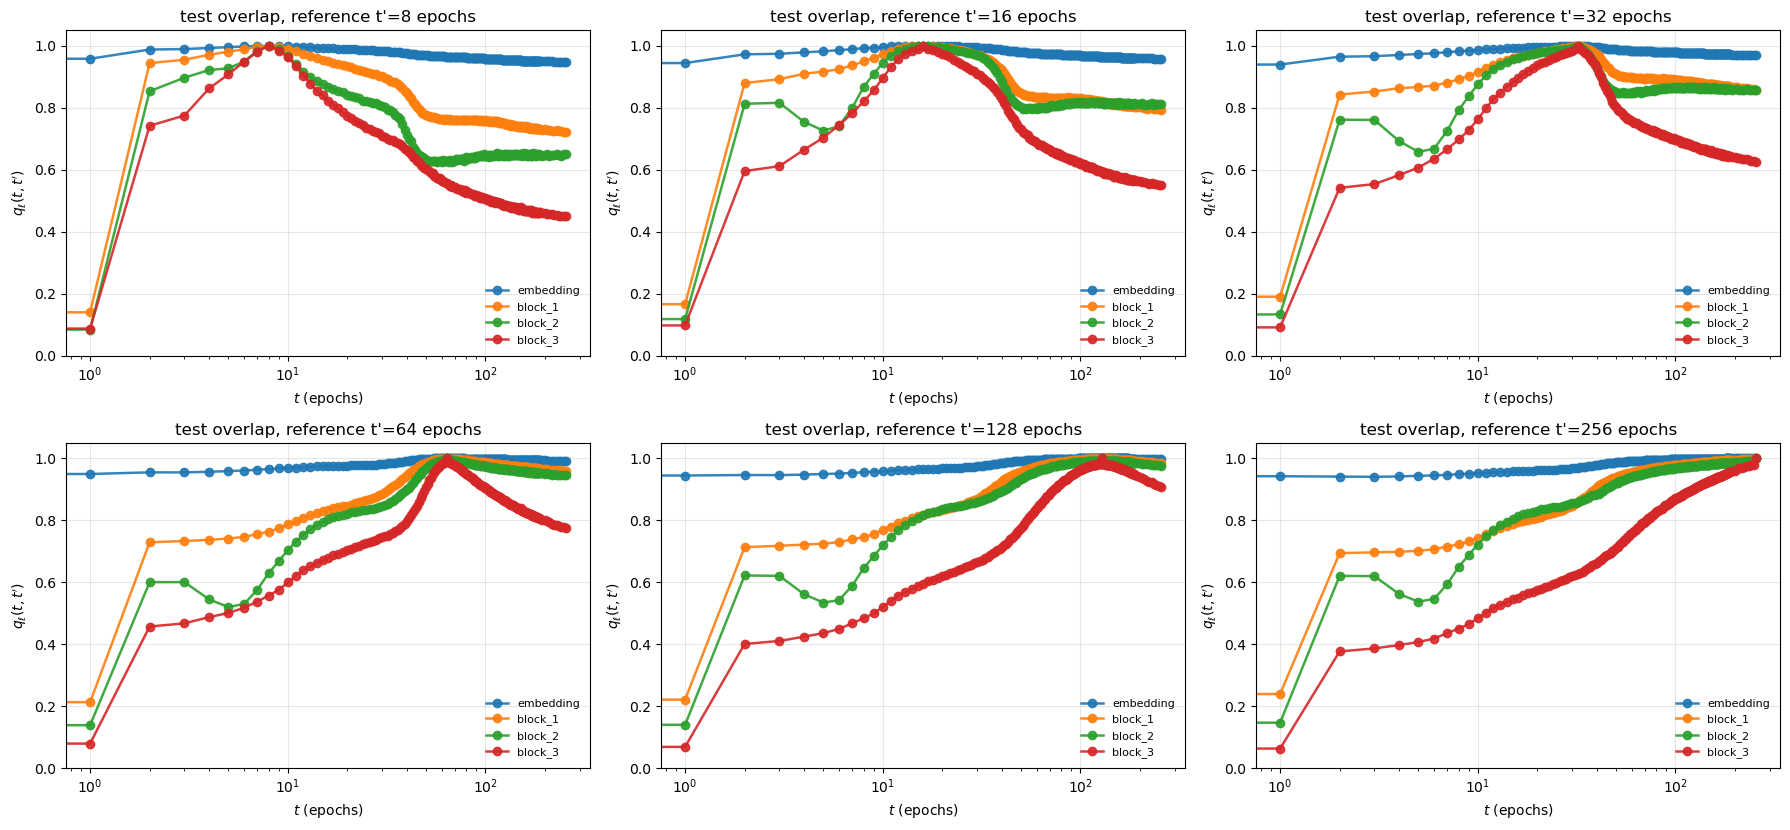

In [19]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L3_ALL_v1",
    output_name="overlap_uniform_M_L3_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)

/tmp/ipykernel_15494/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

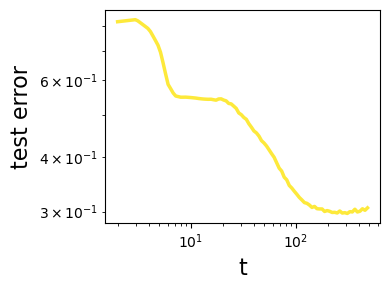

In [12]:
res = np.load("results/save_uniform_M_L3_T6_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


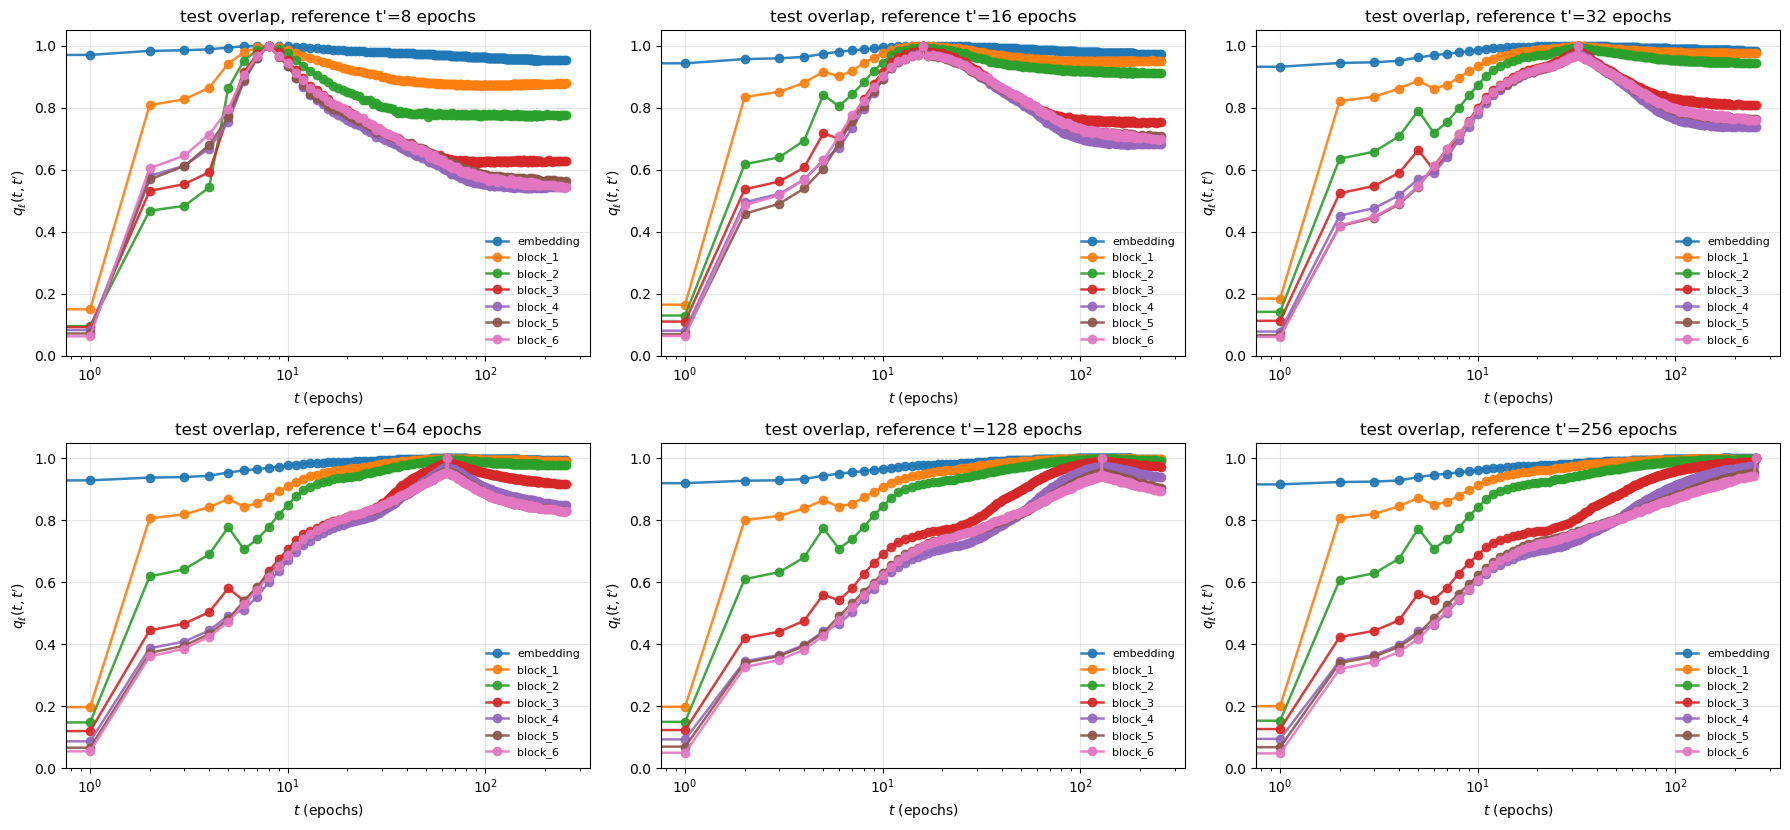

In [26]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L3_T6_ALL_v1",
    output_name="overlap_uniform_M_L3_T6_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)

/tmp/ipykernel_15494/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

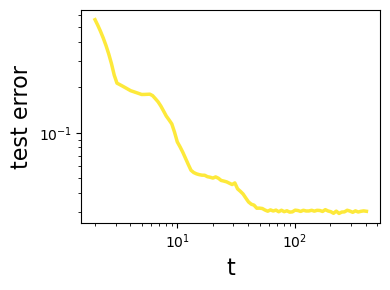

In [16]:
res = np.load("results/save_uniform_M_L4_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


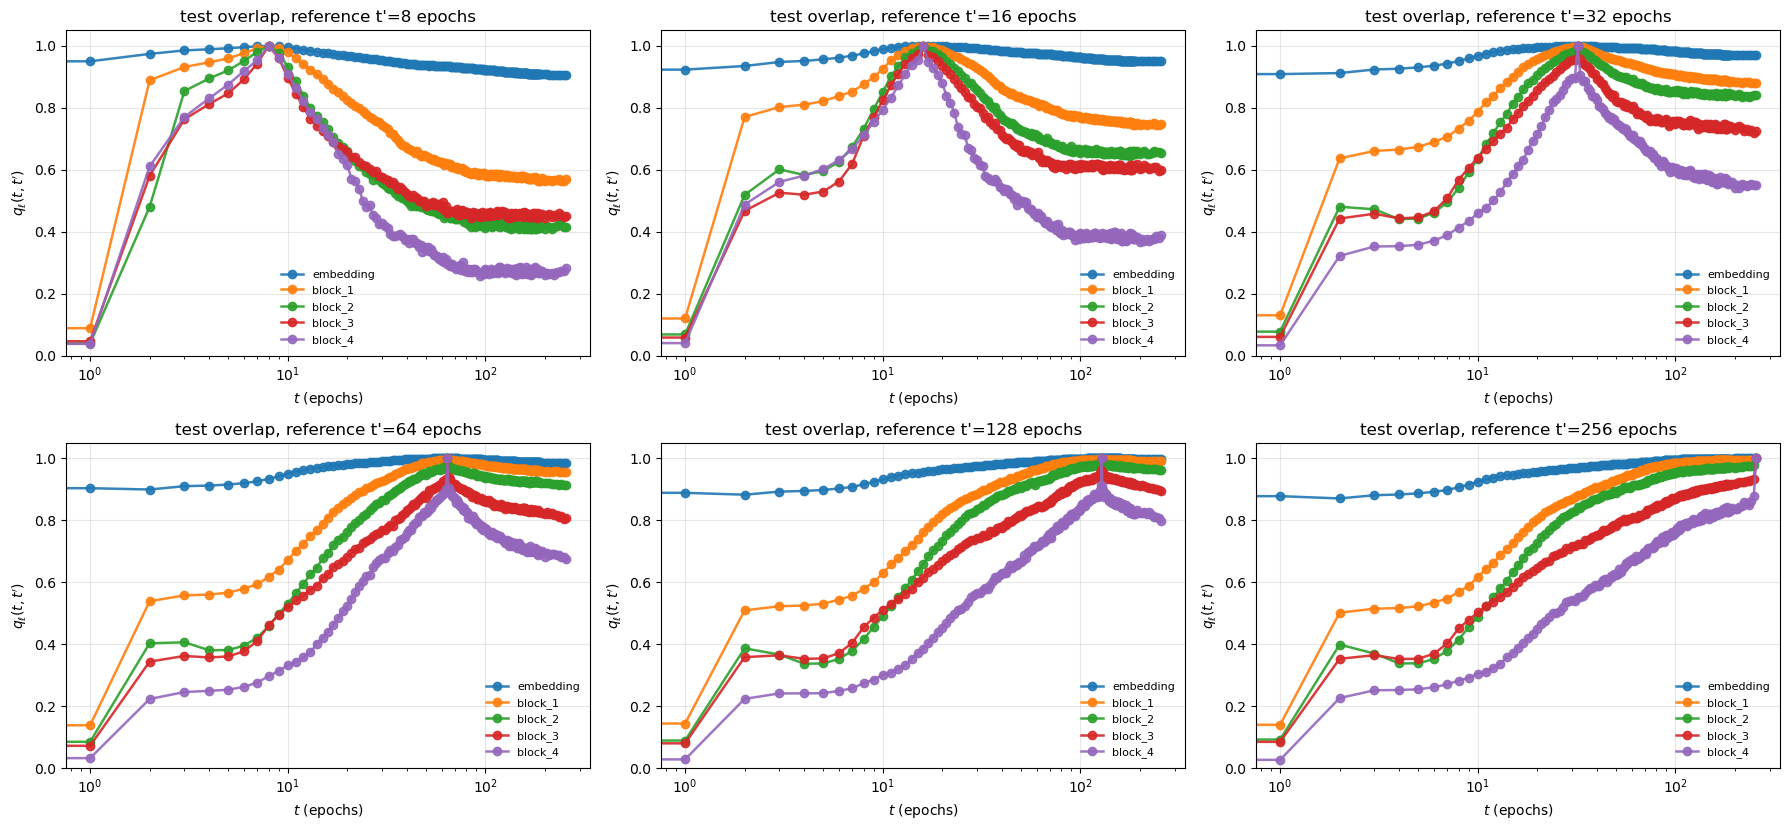

In [27]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L4_ALL_v1",
    output_name="overlap_uniform_M_L4_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)

/tmp/ipykernel_8419/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

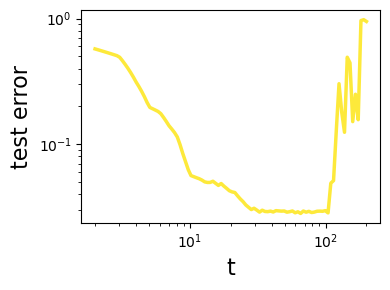

In [41]:
res = np.load("results/save_uniform_M_L4_T8_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


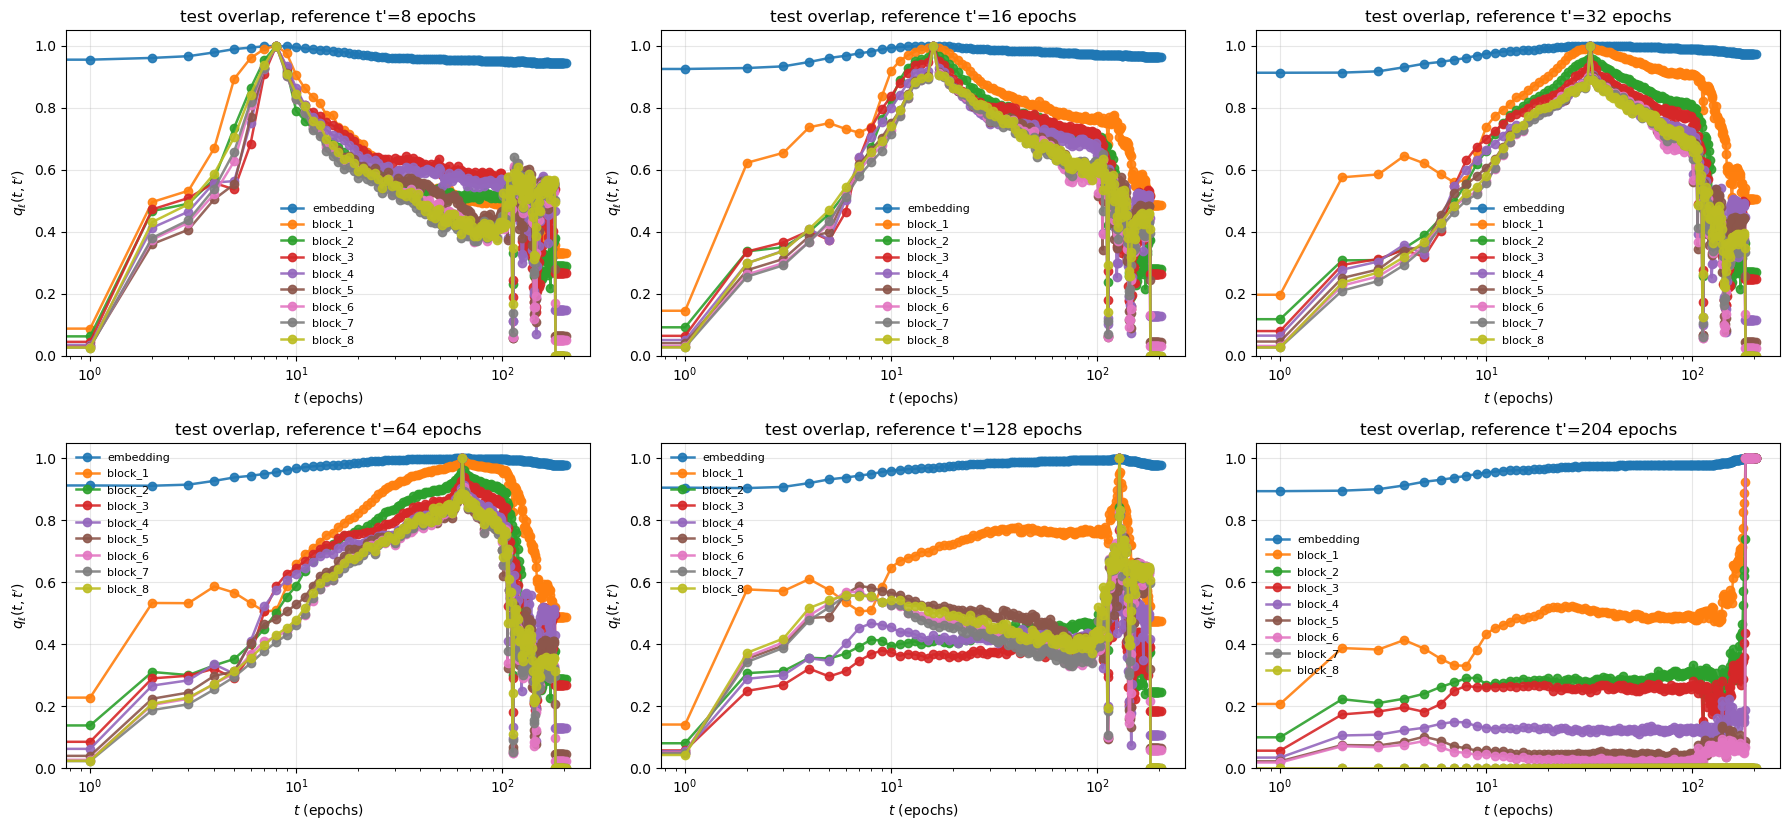

In [28]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L4_T8_ALL_v1",
    output_name="overlap_uniform_M_L4_T8_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)

/tmp/ipykernel_15494/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

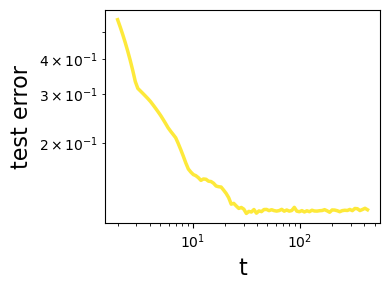

In [22]:
res = np.load("results/save_uniform_M_L5_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


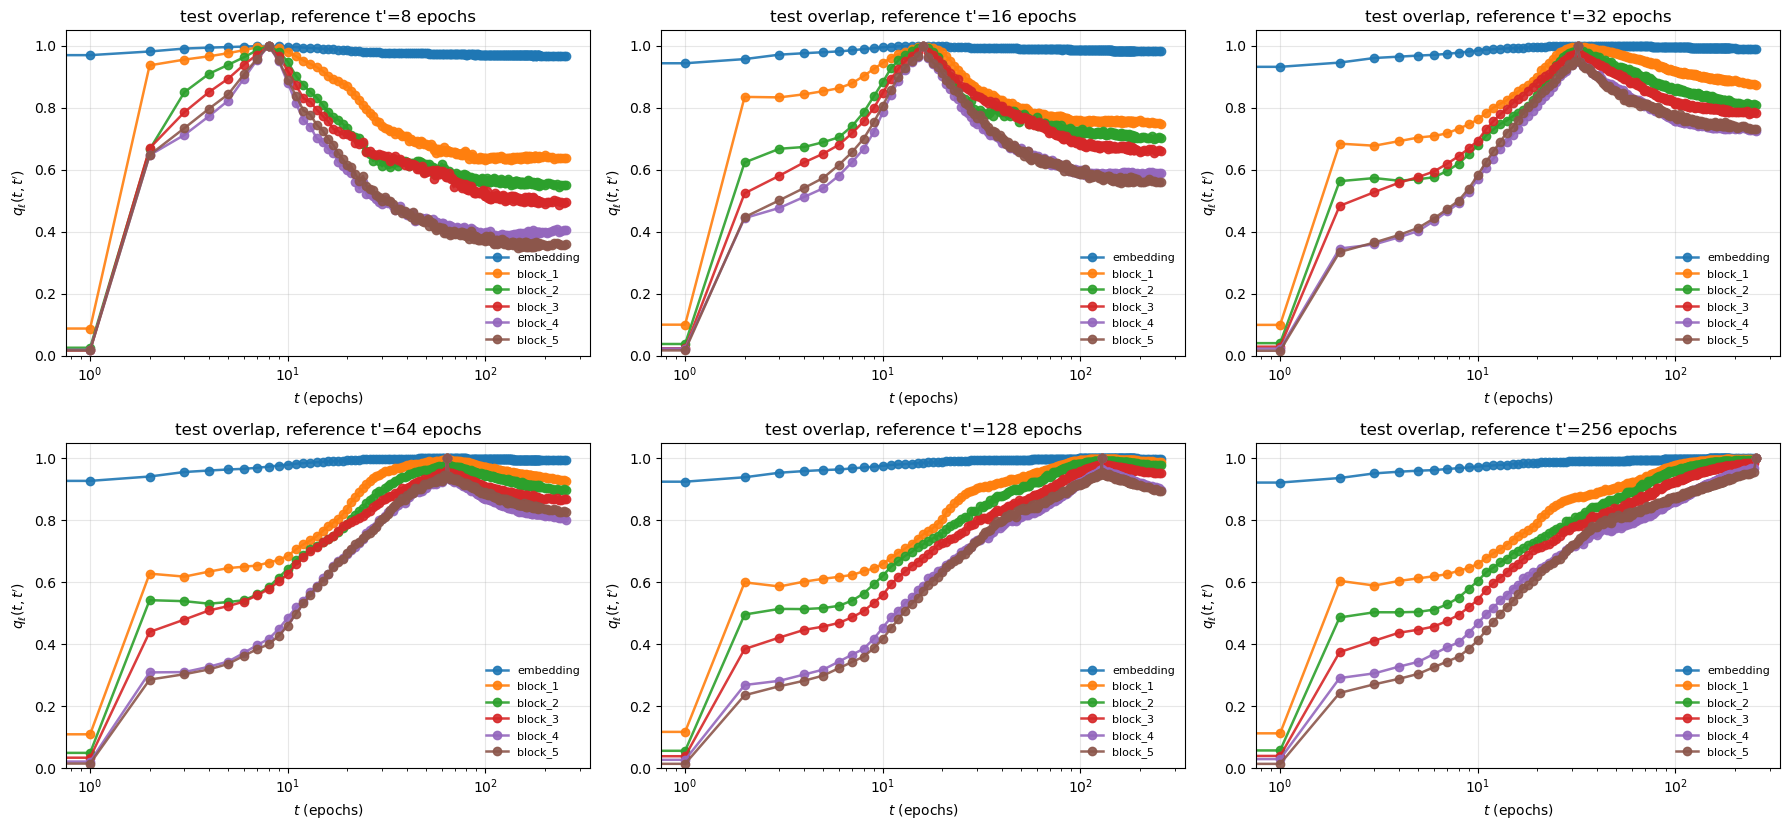

In [29]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L5_ALL_v1",
    output_name="overlap_uniform_M_L5_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)

/tmp/ipykernel_8419/1659121427.py:529: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 400x300 with 1 Axes>, <Axes: xlabel='t', ylabel='test error'>)

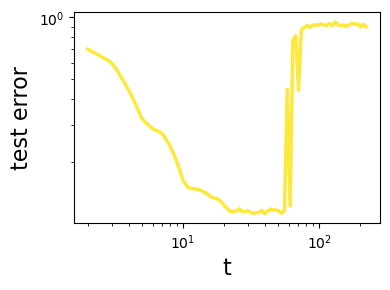

In [47]:
res = np.load("results/save_uniform_M_L5_T10_v1.npy", allow_pickle=True).item()

plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
    lw=2.5,
    figsize = (4,3)
)


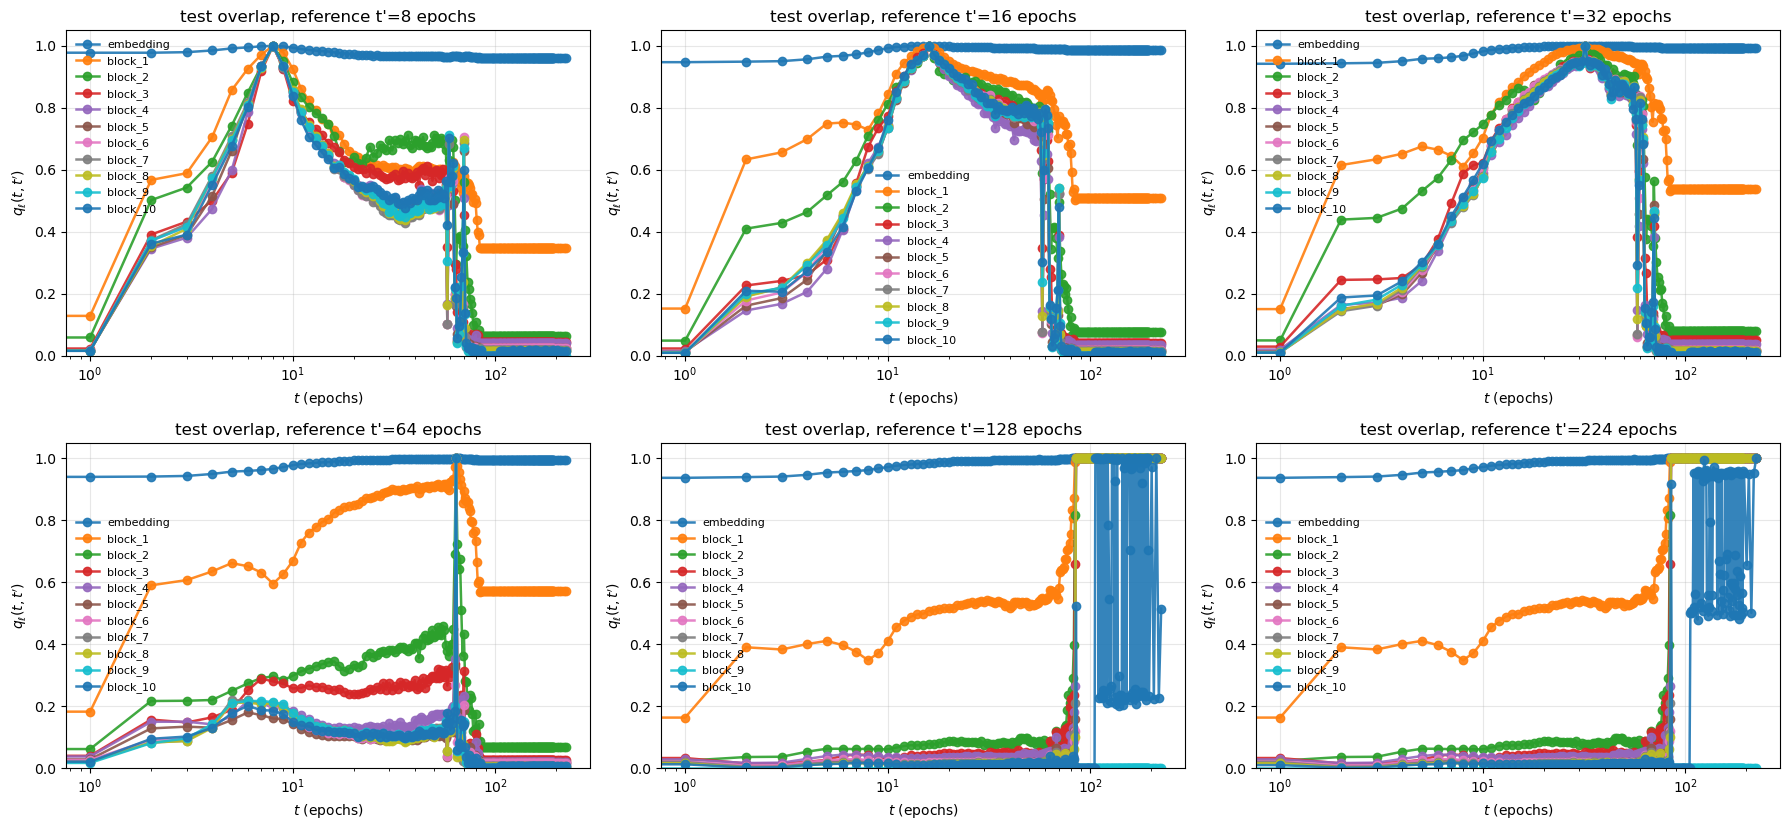

In [30]:
fig, axs, info = plot_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/theory-language-modelling/results/overlap_uniform_M_L5_T10_ALL_v1",
    output_name="overlap_uniform_M_L5_T10_ALL_v1",
    split="test",
    reference_times=[8, 16, 32, 64, 128, 256],
    time_key="epochs",
    x_mode="absolute",
    only_t_ge_tprime=False,
)